In [4]:
import pandas as pd

df = pd.read_csv('../data/menstrual_cycle_dataset_with_factors.csv')

print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

df.head()

Filas y columnas: (895, 12)

Columnas:
['User ID', 'Age', 'BMI', 'Stress Level', 'Exercise Frequency', 'Sleep Hours', 'Diet', 'Cycle Start Date', 'Cycle Length', 'Period Length', 'Next Cycle Start Date', 'Symptoms']


,User ID,Age,BMI,Stress Level,Exercise Frequency,Sleep Hours,Diet,Cycle Start Date,Cycle Length,Period Length,Next Cycle Start Date,Symptoms
0,1,18,29.28,2,Moderate,5.4,Low Carb,2024-11-13 20:52:34.915012,26,7,2024-12-09 20:52:34.915012,Headache
1,1,18,29.28,2,Moderate,5.4,Low Carb,2024-12-09 20:52:34.915012,32,5,2025-01-10 20:52:34.915012,Fatigue
2,1,18,29.28,2,Moderate,5.4,Low Carb,2025-01-10 20:52:34.915012,41,7,2025-02-20 20:52:34.915012,Fatigue
3,1,18,29.28,2,Moderate,5.4,Low Carb,2025-02-20 20:52:34.915012,27,3,2025-03-19 20:52:34.915012,Fatigue
4,1,18,29.28,2,Moderate,5.4,Low Carb,2025-03-19 20:52:34.915012,42,5,2025-04-30 20:52:34.915012,Cramps


In [5]:
# Tipos de datos y valores nulos
print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nValores únicos en 'Symptoms':")
print(df['Symptoms'].unique())

print("\nValores únicos en 'Diet':")
print(df['Diet'].unique())

print("\nUsuarias únicas (User ID):", df['User ID'].nunique())

Tipos de datos:
User ID                    int64
Age                        int64
BMI                      float64
Stress Level               int64
Exercise Frequency           str
Sleep Hours              float64
Diet                         str
Cycle Start Date             str
Cycle Length               int64
Period Length              int64
Next Cycle Start Date        str
Symptoms                     str
dtype: object

Valores nulos por columna:
User ID                  0
Age                      0
BMI                      0
Stress Level             0
Exercise Frequency       0
Sleep Hours              0
Diet                     0
Cycle Start Date         0
Cycle Length             0
Period Length            0
Next Cycle Start Date    0
Symptoms                 0
dtype: int64

Valores únicos en 'Symptoms':
<StringArray>
['Headache', 'Fatigue', 'Cramps', 'Mood Swings', 'Bloating']
Length: 5, dtype: str

Valores únicos en 'Diet':
<StringArray>
['Low Carb', 'Vegetarian', 'Balanced', '

In [6]:
print(df['Symptoms'].unique())
print("\nNúmero de categorías distintas de síntomas:", df['Symptoms'].nunique())

<StringArray>
['Headache', 'Fatigue', 'Cramps', 'Mood Swings', 'Bloating']
Length: 5, dtype: str

Número de categorías distintas de síntomas: 5


In [7]:
import sqlite3

# Crear conexión (esto crea el archivo femcycle.db si no existe)
conn = sqlite3.connect('../femcycle.db')

# Cargar el dataframe a una tabla SQL llamada 'ciclos'
df.to_sql('ciclos', conn, if_exists='replace', index=False)

print("Base de datos creada y tabla 'ciclos' cargada correctamente")
conn.close()

Base de datos creada y tabla 'ciclos' cargada correctamente


In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('../femcycle.db')

query = """
SELECT 
    "User ID",
    "Cycle Start Date",
    "Cycle Length",
    "Period Length"
FROM ciclos
WHERE "Cycle Length" < 21 OR "Cycle Length" > 35;
"""

anomalias = pd.read_sql(query, conn)
print("Número de ciclos anómalos encontrados:", len(anomalias))
anomalias

Número de ciclos anómalos encontrados: 503


,User ID,Cycle Start Date,Cycle Length,Period Length
0,1,2025-01-10 20:52:34.915012,41,7
1,1,2025-03-19 20:52:34.915012,42,5
2,1,2025-04-30 20:52:34.915012,41,5
3,1,2025-07-11 20:52:34.915012,48,7
4,1,2025-09-26 20:52:34.915012,47,4
...,...,...,...,...
498,99,2024-10-30 20:52:34.918906,50,7
499,100,2023-09-28 20:52:34.918945,46,3
500,100,2023-11-13 20:52:34.918945,49,5
501,100,2024-01-01 20:52:34.918945,42,4


## Finding: Cycle Length Outside the "Standard" Clinical Range

The traditional clinical benchmark considers a "normal" cycle to be between 
21-35 days, with 28 days as the reference average. However, the literature 
acknowledges significant individual variability, and some people have cycles 
that are regular but longer (functional oligomenorrhea, not necessarily 
pathological).

In this dataset, the mean cycle length is 37.4 days (median 37), with 56% of 
cycles falling above 35 days. This suggests the simulated population 
represents a profile of naturally longer cycles, not necessarily "abnormal" 
in the clinical sense.

For this reason, we adjust the outlier detection criteria: instead of using 
a fixed clinical range (21-35), we use a statistical approach based on 
percentiles (P5-P95) specific to this population, keeping the clinical 
benchmark as context rather than as an exclusion filter.

In [9]:
print(df['Cycle Length'].describe())
print("\nDistribución por rangos:")
print(pd.cut(df['Cycle Length'], bins=[0, 21, 28, 35, 100]).value_counts().sort_index())

count    895.000000
mean      37.373184
std        7.465008
min       25.000000
25%       31.000000
50%       37.000000
75%       43.000000
max       50.000000
Name: Cycle Length, dtype: float64

Distribución por rangos:
Cycle Length
(0, 21]        0
(21, 28]     136
(28, 35]     256
(35, 100]    503
Name: count, dtype: int64


In [10]:
adjusted_query = """
WITH percentiles AS (
    SELECT 
        (SELECT "Cycle Length" FROM ciclos ORDER BY "Cycle Length" LIMIT 1 OFFSET CAST(0.05 * (SELECT COUNT(*) FROM ciclos) AS INT)) AS p5,
        (SELECT "Cycle Length" FROM ciclos ORDER BY "Cycle Length" LIMIT 1 OFFSET CAST(0.95 * (SELECT COUNT(*) FROM ciclos) AS INT)) AS p95
)
SELECT 
    c."User ID",
    c."Cycle Start Date",
    c."Cycle Length",
    c."Period Length"
FROM ciclos c, percentiles p
WHERE c."Cycle Length" < p.p5 OR c."Cycle Length" > p.p95;
"""

adjusted_outliers = pd.read_sql(adjusted_query, conn)
print("Number of real outliers (P5-P95):", len(adjusted_outliers))
adjusted_outliers

Number of real outliers (P5-P95): 66


,User ID,Cycle Start Date,Cycle Length,Period Length
0,3,2024-09-29 20:52:34.915155,50,4
1,3,2024-12-28 20:52:34.915155,25,5
2,6,2023-10-19 20:52:34.915275,50,5
3,6,2024-01-23 20:52:34.915275,25,5
4,8,2023-09-23 20:52:34.915353,25,7
...,...,...,...,...
61,92,2026-01-11 20:52:34.918686,50,3
62,96,2024-04-28 20:52:34.918822,50,5
63,98,2025-05-10 20:52:34.918876,50,3
64,99,2024-05-03 20:52:34.918906,25,5


In [11]:
conn = sqlite3.connect('../femcycle.db')

In [16]:
phase_ranges_query = """
SELECT
    "User ID",
    "Cycle Start Date",
    "Cycle Length",
    "Period Length",
    "Cycle Start Date" AS menstrual_start,
    date("Cycle Start Date", '+' || ("Period Length" - 1) || ' days') AS menstrual_end,
    date("Cycle Start Date", '+' || "Period Length" || ' days') AS follicular_start,
    date("Cycle Start Date", '+' || ("Cycle Length" - 15) || ' days') AS follicular_end,
    date("Cycle Start Date", '+' || ("Cycle Length" - 14) || ' days') AS ovulation_day,
    date("Cycle Start Date", '+' || ("Cycle Length" - 13) || ' days') AS luteal_start,
    date("Cycle Start Date", '+' || ("Cycle Length" - 1) || ' days') AS luteal_end
FROM ciclos;
"""

phase_ranges = pd.read_sql(phase_ranges_query, conn)
phase_ranges

,User ID,Cycle Start Date,Cycle Length,Period Length,menstrual_start,menstrual_end,follicular_start,follicular_end,ovulation_day,luteal_start,luteal_end
0,1,2024-11-13 20:52:34.915012,26,7,2024-11-13 20:52:34.915012,2024-11-19,2024-11-20,2024-11-24,2024-11-25,2024-11-26,2024-12-08
1,1,2024-12-09 20:52:34.915012,32,5,2024-12-09 20:52:34.915012,2024-12-13,2024-12-14,2024-12-26,2024-12-27,2024-12-28,2025-01-09
2,1,2025-01-10 20:52:34.915012,41,7,2025-01-10 20:52:34.915012,2025-01-16,2025-01-17,2025-02-05,2025-02-06,2025-02-07,2025-02-19
3,1,2025-02-20 20:52:34.915012,27,3,2025-02-20 20:52:34.915012,2025-02-22,2025-02-23,2025-03-04,2025-03-05,2025-03-06,2025-03-18
4,1,2025-03-19 20:52:34.915012,42,5,2025-03-19 20:52:34.915012,2025-03-23,2025-03-24,2025-04-15,2025-04-16,2025-04-17,2025-04-29
...,...,...,...,...,...,...,...,...,...,...,...
890,100,2023-08-24 20:52:34.918945,35,5,2023-08-24 20:52:34.918945,2023-08-28,2023-08-29,2023-09-13,2023-09-14,2023-09-15,2023-09-27
891,100,2023-09-28 20:52:34.918945,46,3,2023-09-28 20:52:34.918945,2023-09-30,2023-10-01,2023-10-29,2023-10-30,2023-10-31,2023-11-12
892,100,2023-11-13 20:52:34.918945,49,5,2023-11-13 20:52:34.918945,2023-11-17,2023-11-18,2023-12-17,2023-12-18,2023-12-19,2023-12-31
893,100,2024-01-01 20:52:34.918945,42,4,2024-01-01 20:52:34.918945,2024-01-04,2024-01-05,2024-01-28,2024-01-29,2024-01-30,2024-02-11


In [17]:
print(phase_ranges.shape)

(895, 11)


In [18]:
# General distribution of numeric lifestyle variables
print("Stress Level distribution:")
print(df['Stress Level'].value_counts().sort_index())

print("\nSleep Hours summary:")
print(df['Sleep Hours'].describe())

print("\nExercise Frequency distribution:")
print(df['Exercise Frequency'].value_counts())

print("\nDiet distribution:")
print(df['Diet'].value_counts())

print("\nSymptoms distribution:")
print(df['Symptoms'].value_counts())

Stress Level distribution:
Stress Level
1    183
2    158
3    143
4    227
5    184
Name: count, dtype: int64

Sleep Hours summary:
count    895.000000
mean       6.988715
std        1.216100
min        5.100000
25%        5.700000
50%        7.100000
75%        8.000000
max        9.000000
Name: Sleep Hours, dtype: float64

Exercise Frequency distribution:
Exercise Frequency
High        361
Moderate    280
Low         254
Name: count, dtype: int64

Diet distribution:
Diet
Vegetarian    268
Balanced      258
Low Carb      200
High Sugar    169
Name: count, dtype: int64

Symptoms distribution:
Symptoms
Bloating       204
Fatigue        178
Cramps         177
Headache       175
Mood Swings    161
Name: count, dtype: int64


In [19]:
print("Diet distribution:")
print(df['Diet'].value_counts())

print("\nFull Symptoms distribution:")
print(df['Symptoms'].value_counts())


Diet distribution:
Diet
Vegetarian    268
Balanced      258
Low Carb      200
High Sugar    169
Name: count, dtype: int64

Full Symptoms distribution:
Symptoms
Bloating       204
Fatigue        178
Cramps         177
Headache       175
Mood Swings    161
Name: count, dtype: int64


In [20]:
# Unique users who reported each symptom at least once
unique_users_per_symptom = df.groupby('Symptoms')['User ID'].nunique().sort_values(ascending=False)
print("Unique users reporting each symptom at least once (out of 100 total users):")
print(unique_users_per_symptom)

Unique users reporting each symptom at least once (out of 100 total users):
Symptoms
Headache       90
Bloating       88
Fatigue        88
Cramps         85
Mood Swings    78
Name: User ID, dtype: int64


In [21]:
# Average lifestyle factors by symptom
symptom_analysis = df.groupby('Symptoms').agg({
    'Stress Level': 'mean',
    'Sleep Hours': 'mean',
    'Age': 'mean',
    'BMI': 'mean'
}).round(2)

symptom_analysis

,Stress Level,Sleep Hours,Age,BMI
Symptoms,,,,
Bloating,3.09,6.98,32.20,24.50
Cramps,3.08,6.95,30.50,24.27
Fatigue,3.17,6.96,31.08,24.67
Headache,3.01,7.06,30.34,24.29
Mood Swings,3.04,6.99,30.80,24.71


In [22]:
from scipy import stats

# ANOVA test: is there a statistically significant difference in Stress Level across symptoms?
groups = [group['Stress Level'].values for name, group in df.groupby('Symptoms')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print("\nInterpretation: if p-value > 0.05, there is no statistically significant")
print("difference in Stress Level across symptom groups.")

ANOVA F-statistic: 0.307
P-value: 0.873

Interpretation: if p-value > 0.05, there is no statistically significant
difference in Stress Level across symptom groups.


## Finding: No Significant Relationship Between Individual Lifestyle Factors and Predominant Symptom

Initial hypothesis: stress, sleep, age, or BMI might predict which symptom 
is predominant in a given cycle.

Result: average values for Stress Level, Sleep Hours, Age, and BMI were 
nearly identical across all 5 symptom categories. An ANOVA test on Stress 
Level confirmed this statistically (F=0.307, p=0.873) — well above the 0.05 
significance threshold, meaning any observed differences are due to random 
variation, not a real pattern.

Business takeaway: symptom type does not appear to be driven by a single 
lifestyle factor in isolation. This suggests that either (a) symptom 
occurrence is more strongly tied to hormonal/cycle-phase mechanics not 
captured at the granularity of this dataset, or (b) a combination of 
factors (rather than any single one) would be needed to predict symptoms — 
worth exploring with clustering rather than one-variable-at-a-time comparisons.
Chi-square tests on the categorical variables confirmed the same pattern: 
Diet vs. Symptoms (χ²=14.078, p=0.296) and Exercise Frequency vs. Symptoms 
(χ²=9.944, p=0.269) — neither showed a statistically significant relationship.


In [23]:
from scipy.stats import chi2_contingency

# Chi-square test: Diet vs Symptoms
contingency_diet = pd.crosstab(df['Diet'], df['Symptoms'])
chi2, p_diet, dof, expected = chi2_contingency(contingency_diet)
print(f"Diet vs Symptoms — Chi2: {chi2:.3f}, p-value: {p_diet:.3f}")

# Chi-square test: Exercise Frequency vs Symptoms
contingency_exercise = pd.crosstab(df['Exercise Frequency'], df['Symptoms'])
chi2_ex, p_exercise, dof_ex, expected_ex = chi2_contingency(contingency_exercise)
print(f"Exercise Frequency vs Symptoms — Chi2: {chi2_ex:.3f}, p-value: {p_exercise:.3f}")

Diet vs Symptoms — Chi2: 14.078, p-value: 0.296
Exercise Frequency vs Symptoms — Chi2: 9.944, p-value: 0.269


In [24]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Convert categorical variables to numeric using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Diet', 'Exercise Frequency'], drop_first=True)

# Select features for clustering (numeric lifestyle factors)
features = ['Age', 'BMI', 'Stress Level', 'Sleep Hours'] + \
           [col for col in df_encoded.columns if 'Diet_' in col or 'Exercise Frequency_' in col]

print("Features used for clustering:")
print(features)

X = df_encoded[features]
X.head()

Features used for clustering:
['Age', 'BMI', 'Stress Level', 'Sleep Hours', 'Diet_High Sugar', 'Diet_Low Carb', 'Diet_Vegetarian', 'Exercise Frequency_Low', 'Exercise Frequency_Moderate']


,Age,BMI,Stress Level,Sleep Hours,Diet_High Sugar,Diet_Low Carb,Diet_Vegetarian,Exercise Frequency_Low,Exercise Frequency_Moderate
0,18,29.28,2,5.4,False,True,False,False,True
1,18,29.28,2,5.4,False,True,False,False,True
2,18,29.28,2,5.4,False,True,False,False,True
3,18,29.28,2,5.4,False,True,False,False,True
4,18,29.28,2,5.4,False,True,False,False,True


In [25]:
# Convert True/False to 1/0 (in case they're not already numeric)
X = X.astype(int)

# Scale all features to the same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("\nFirst few rows (scaled):")
print(X_scaled[:5])

Scaled data shape: (895, 9)

First few rows (scaled):
[[-1.57448429  1.58230159 -0.75125772 -1.30838288 -0.48247525  1.86413519
  -0.653783   -0.62948856  1.48203528]
 [-1.57448429  1.58230159 -0.75125772 -1.30838288 -0.48247525  1.86413519
  -0.653783   -0.62948856  1.48203528]
 [-1.57448429  1.58230159 -0.75125772 -1.30838288 -0.48247525  1.86413519
  -0.653783   -0.62948856  1.48203528]
 [-1.57448429  1.58230159 -0.75125772 -1.30838288 -0.48247525  1.86413519
  -0.653783   -0.62948856  1.48203528]
 [-1.57448429  1.58230159 -0.75125772 -1.30838288 -0.48247525  1.86413519
  -0.653783   -0.62948856  1.48203528]]


Matplotlib is building the font cache; this may take a moment.


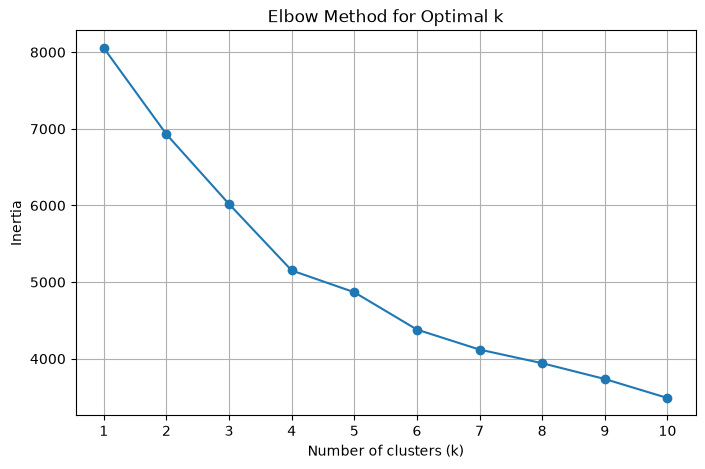

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Try different numbers of clusters and record how well each fits
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [27]:
# Train final K-means model with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Number of cycles in each cluster:")
print(df['Cluster'].value_counts().sort_index())

Number of cycles in each cluster:
Cluster
0    169
1    201
2    325
3    200
Name: count, dtype: int64


In [28]:
# Profile each cluster: average lifestyle characteristics
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'BMI': 'mean',
    'Stress Level': 'mean',
    'Sleep Hours': 'mean',
    'Cycle Length': 'mean'
}).round(2)

print(cluster_profile)

print("\nDiet distribution by cluster:")
print(pd.crosstab(df['Cluster'], df['Diet']))

print("\nExercise Frequency distribution by cluster:")
print(pd.crosstab(df['Cluster'], df['Exercise Frequency']))

           Age    BMI  Stress Level  Sleep Hours  Cycle Length
Cluster                                                       
0        31.11  23.67          3.11         7.10         37.33
1        29.05  26.73          2.84         7.63         37.52
2        32.57  23.01          2.99         6.71         37.32
3        30.44  25.31          3.44         6.71         37.35

Diet distribution by cluster:
Diet     Balanced  High Sugar  Low Carb  Vegetarian
Cluster                                            
0               0         169         0           0
1              52           0         0         149
2             206           0         0         119
3               0           0       200           0

Exercise Frequency distribution by cluster:
Exercise Frequency  High  Low  Moderate
Cluster                                
0                     56   46        67
1                     53    0       148
2                    176  149         0
3                     76   59     

In [29]:
from scipy.stats import chi2_contingency

contingency_cluster = pd.crosstab(df['Cluster'], df['Symptoms'])
print(contingency_cluster)

chi2_cluster, p_cluster, dof_cluster, expected_cluster = chi2_contingency(contingency_cluster)
print(f"\nCluster vs Symptoms — Chi2: {chi2_cluster:.3f}, p-value: {p_cluster:.3f}")

Symptoms  Bloating  Cramps  Fatigue  Headache  Mood Swings
Cluster                                                   
0               35      28       29        42           35
1               40      47       30        44           40
2               78      63       71        57           56
3               51      39       48        32           30

Cluster vs Symptoms — Chi2: 16.749, p-value: 0.159


In [30]:
# Re-cluster using only numeric variables
numeric_features = ['Age', 'BMI', 'Stress Level', 'Sleep Hours']
X_numeric = df[numeric_features]

scaler_numeric = StandardScaler()
X_numeric_scaled = scaler_numeric.fit_transform(X_numeric)

kmeans_numeric = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_numeric'] = kmeans_numeric.fit_predict(X_numeric_scaled)

# Profile
print(df.groupby('Cluster_numeric')[numeric_features].mean().round(2))

# Chi-square test against symptoms
contingency_numeric = pd.crosstab(df['Cluster_numeric'], df['Symptoms'])
chi2_num, p_num, dof_num, expected_num = chi2_contingency(contingency_numeric)
print(f"\nNumeric-only Cluster vs Symptoms — Chi2: {chi2_num:.3f}, p-value: {p_num:.3f}")

                   Age    BMI  Stress Level  Sleep Hours
Cluster_numeric                                         
0                34.95  22.69          3.85         7.89
1                25.90  25.14          1.46         7.73
2                30.01  27.79          4.13         6.44
3                33.65  21.90          2.84         5.64

Numeric-only Cluster vs Symptoms — Chi2: 10.028, p-value: 0.614


## Finding: Lifestyle Profiles Do Not Predict Predominant Symptom

Two clustering approaches were tested to see if combinations of lifestyle 
factors (rather than single variables) could predict which symptom is 
predominant in a given cycle:

1. **Mixed clustering** (numeric + categorical: Age, BMI, Stress, Sleep, 
   Diet, Exercise) — resulted in clusters largely driven by Diet category, 
   with no significant association to Symptoms (χ²=16.749, p=0.159).

2. **Numeric-only clustering** (Age, BMI, Stress, Sleep) — produced 4 
   well-differentiated profiles (e.g., a younger/low-stress group vs. an 
   older/high-stress/low-sleep group), yet still showed no significant 
   association with Symptoms (χ²=10.028, p=0.614).

**Conclusion:** in this dataset, the predominant symptom reported per cycle 
does not appear to be explained by demographic or lifestyle factors — 
individually or in combination. This is consistent with the clinical 
understanding that symptom presentation is primarily driven by hormonal 
fluctuations across the cycle, which this dataset does not capture at the 
daily level (only one symptom is recorded per full cycle).

**Recommendation for product teams:** rather than personalizing content by 
lifestyle profile, symptom-tracking features should focus on hormonal 
cycle phase and day-level logging to capture within-cycle variation — the 
signal this dataset shows is simply not present at the lifestyle-factor level.